<a href="https://colab.research.google.com/github/mulugetabernabas33-source/AI-INSA-_project/blob/main/AIproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics roboflow -q

import torch, os, random, shutil
from roboflow import Roboflow
from ultralytics import YOLO
from google.colab import drive

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU - check Runtime settings")

drive.mount('/content/drive')
backup_dir = "/content/drive/MyDrive/plate_project_backup"
os.makedirs(backup_dir, exist_ok=True)

rf = Roboflow(api_key="PASTE_YOUR_KEY_HERE")
rf.workspace("rjacaac1").project("ua-detrac-dataset-10k").version(1).download("yolov8")
rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e").version(4).download("yolov8")

random.seed(42)
def make_subset(src_root, dst_root, n_train, n_val):
    for split, n in [("train", n_train), ("valid", n_val)]:
        src_img, src_lbl = f"{src_root}/{split}/images", f"{src_root}/{split}/labels"
        dst_img, dst_lbl = f"{dst_root}/{split}/images", f"{dst_root}/{split}/labels"
        os.makedirs(dst_img, exist_ok=True); os.makedirs(dst_lbl, exist_ok=True)
        sample = random.sample(os.listdir(src_img), min(n, len(os.listdir(src_img))))
        for img in sample:
            base = os.path.splitext(img)[0]
            shutil.copy(f"{src_img}/{img}", f"{dst_img}/{img}")
            lp = f"{src_lbl}/{base}.txt"
            shutil.copy(lp, f"{dst_lbl}/{base}.txt") if os.path.exists(lp) else open(f"{dst_lbl}/{base}.txt",'w').close()
    print(f"{dst_root} subset done")

make_subset("UA-DETRAC-DATASET-10K-1", "vehicle_subset", 2000, 500)
make_subset("License-Plate-Recognition-4", "plate_subset", 2000, 500)

for lbl_dir in ["vehicle_subset/train/labels", "vehicle_subset/valid/labels"]:
    for f in os.listdir(lbl_dir):
        p = f"{lbl_dir}/{f}"
        lines = [ln.split() for ln in open(p) if ln.strip()]
        for ln in lines: ln[0] = "0"
        open(p, 'w').write("\n".join(" ".join(ln) for ln in lines))

open("vehicle_subset/data.yaml","w").write("path: /content/vehicle_subset\ntrain: train/images\nval: valid/images\nnames:\n  0: vehicle\n")
open("plate_subset/data.yaml","w").write("path: /content/plate_subset\ntrain: train/images\nval: valid/images\nnames:\n  0: plate\n")

print("Data ready. Training Stage 1...")
vehicle_model = YOLO('yolov8n.pt')
vehicle_model.train(data='vehicle_subset/data.yaml', epochs=30, imgsz=640, batch=16, patience=8, device=0, project='runs/vehicle', name='v8n_vehicle')
shutil.copy("runs/vehicle/v8n_vehicle/weights/best.pt", f"{backup_dir}/vehicle_best.pt")
print("Stage 1 backed up.")

print("Training Stage 2...")
plate_model = YOLO('yolov8n.pt')
plate_model.train(data='plate_subset/data.yaml', epochs=30, imgsz=416, batch=32, patience=8, device=0, project='runs/plate', name='v8n_plate')
shutil.copy("runs/plate/v8n_plate/weights/best.pt", f"{backup_dir}/plate_best.pt")
print("Stage 2 backed up.")

print("\n=== ALL DONE ===")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 1.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4
Mounted at /content/drive
upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref

RoboflowError: {"error":{"message":"This API key does not exist (or has been revoked).","status":401,"type":"OAuthException","hint":"You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours."}}

In [ ]:
rf = Roboflow(api_key="z6yM8DPHWKF0L4qXnWQS")

In [ ]:
rf = Roboflow(api_key="ne9nxn5FoVhbAx0WQOHS")

In [ ]:
import torch, os, random, shutil
from ultralytics import YOLO
from google.colab import drive

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

drive.mount('/content/drive')
backup_dir = "/content/drive/MyDrive/plate_project_backup"
os.makedirs(backup_dir, exist_ok=True)

rf.workspace("rjacaac1").project("ua-detrac-dataset-10k").version(1).download("yolov8")
rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e").version(4).download("yolov8")

random.seed(42)
def make_subset(src_root, dst_root, n_train, n_val):
    for split, n in [("train", n_train), ("valid", n_val)]:
        src_img, src_lbl = f"{src_root}/{split}/images", f"{src_root}/{split}/labels"
        dst_img, dst_lbl = f"{dst_root}/{split}/images", f"{dst_root}/{split}/labels"
        os.makedirs(dst_img, exist_ok=True); os.makedirs(dst_lbl, exist_ok=True)
        sample = random.sample(os.listdir(src_img), min(n, len(os.listdir(src_img))))
        for img in sample:
            base = os.path.splitext(img)[0]
            shutil.copy(f"{src_img}/{img}", f"{dst_img}/{img}")
            lp = f"{src_lbl}/{base}.txt"
            shutil.copy(lp, f"{dst_lbl}/{base}.txt") if os.path.exists(lp) else open(f"{dst_lbl}/{base}.txt",'w').close()
    print(f"{dst_root} subset done")

make_subset("UA-DETRAC-DATASET-10K-1", "vehicle_subset", 2000, 500)
make_subset("License-Plate-Recognition-4", "plate_subset", 2000, 500)

for lbl_dir in ["vehicle_subset/train/labels", "vehicle_subset/valid/labels"]:
    for f in os.listdir(lbl_dir):
        p = f"{lbl_dir}/{f}"
        lines = [ln.split() for ln in open(p) if ln.strip()]
        for ln in lines: ln[0] = "0"
        open(p, 'w').write("\n".join(" ".join(ln) for ln in lines))

open("vehicle_subset/data.yaml","w").write("path: /content/vehicle_subset\ntrain: train/images\nval: valid/images\nnames:\n  0: vehicle\n")
open("plate_subset/data.yaml","w").write("path: /content/plate_subset\ntrain: train/images\nval: valid/images\nnames:\n  0: plate\n")

print("Data ready. Training Stage 1...")
vehicle_model = YOLO('yolov8n.pt')
vehicle_model.train(data='vehicle_subset/data.yaml', epochs=30, imgsz=640, batch=16, patience=8, device=0, project='runs/vehicle', name='v8n_vehicle')
shutil.copy("runs/vehicle/v8n_vehicle/weights/best.pt", f"{backup_dir}/vehicle_best.pt")
print("Stage 1 backed up.")

print("Training Stage 2...")
plate_model = YOLO('yolov8n.pt')
plate_model.train(data='plate_subset/data.yaml', epochs=30, imgsz=416, batch=32, patience=8, device=0, project='runs/plate', name='v8n_plate')
shutil.copy("runs/plate/v8n_plate/weights/best.pt", f"{backup_dir}/plate_best.pt")
print("Stage 2 backed up.")

print("\n=== ALL DONE ===")

GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to UA-DETRAC-DATASET-10K-1 in yolov8:: 100%|██████████| 33380/33380 [00:05<00:00, 6064.07it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-4 in yolov8:: 100%|██████████| 48488/48488 [00:09<00:00, 5238.17it/s]


vehicle_subset subset done
plate_subset subset done
Data ready. Training Stage 1...
Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mo

FileNotFoundError: [Errno 2] No such file or directory: 'runs/vehicle/v8n_vehicle/weights/best.pt'

In [ ]:
import shutil, os

# Fix: copy Stage 1 weights with the correct path
os.makedirs(backup_dir, exist_ok=True)
shutil.copy("/content/runs/detect/runs/vehicle/v8n_vehicle/weights/best.pt", f"{backup_dir}/vehicle_best.pt")
print("Stage 1 weights backed up to Drive.")

# Now Stage 2 training
from ultralytics import YOLO
print("Training Stage 2...")
plate_model = YOLO('yolov8n.pt')
plate_model.train(data='plate_subset/data.yaml', epochs=30, imgsz=416, batch=32, patience=8, device=0, project='runs/plate', name='v8n_plate')
shutil.copy("/content/runs/detect/runs/plate/v8n_plate/weights/best.pt", f"{backup_dir}/plate_best.pt")
print("Stage 2 backed up.")

print("\n=== ALL DONE ===")

Stage 1 weights backed up to Drive.
Training Stage 2...
Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plate_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mult

In [6]:
plate_metrics = plate_model.val(data='plate_subset/data.yaml')
print("Plate mAP@50:", plate_metrics.box.map50)
print("Plate mAP@50-95:", plate_metrics.box.map)
print("Plate Precision:", plate_metrics.box.mp)
print("Plate Recall:", plate_metrics.box.mr)

Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1298.3±296.9 MB/s, size: 37.6 KB)
val: Scanning /content/plate_subset/valid/labels.cache... 500 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 41.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.5it/s 7.1s
                   all        500        527      0.978      0.931      0.957      0.625
Speed: 1.4ms preprocess, 3.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val
Plate mAP@50: 0.9572497795428941
Plate mAP@50-95: 0.624913439911267
Plate Precision: 0.9780733590666117
Plate Recall: 0.9310688204193547


In [7]:
import os
test_images = os.listdir("vehicle_subset/valid/images")
test_img_path = f"vehicle_subset/valid/images/{test_images[0]}"
print("Using test image:", test_img_path)

Using test image: vehicle_subset/valid/images/MVI_40192_img00053_jpg.rf.281342b0181fdc9ab99a5a527791bc7f.jpg


In [8]:
import cv2

def detect_vehicles_and_plates(img_path, vehicle_model, plate_model, conf_threshold=0.4):
    img = cv2.imread(img_path)
    vehicle_results = vehicle_model(img, conf=conf_threshold, verbose=False)[0]

    detections = []
    for box in vehicle_results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        vehicle_crop = img[y1:y2, x1:x2]
        if vehicle_crop.size == 0:
            continue

        plate_results = plate_model(vehicle_crop, conf=conf_threshold, verbose=False)[0]
        plates_in_crop = []
        for pbox in plate_results.boxes:
            px1, py1, px2, py2 = map(int, pbox.xyxy[0])
            plates_in_crop.append({
                "box": (x1 + px1, y1 + py1, x1 + px2, y1 + py2),
                "conf": float(pbox.conf)
            })

        detections.append({
            "vehicle_box": (x1, y1, x2, y2),
            "vehicle_conf": float(box.conf),
            "plates": plates_in_crop
        })

    return img, detections

img, detections = detect_vehicles_and_plates(test_img_path, vehicle_model, plate_model)
print(f"Found {len(detections)} vehicle(s)")
for i, d in enumerate(detections):
    print(f"  Vehicle {i}: conf={d['vehicle_conf']:.2f}, plates found={len(d['plates'])}")

Found 19 vehicle(s)
  Vehicle 0: conf=0.90, plates found=0
  Vehicle 1: conf=0.90, plates found=0
  Vehicle 2: conf=0.89, plates found=1
  Vehicle 3: conf=0.89, plates found=0
  Vehicle 4: conf=0.88, plates found=0
  Vehicle 5: conf=0.87, plates found=0
  Vehicle 6: conf=0.87, plates found=0
  Vehicle 7: conf=0.86, plates found=0
  Vehicle 8: conf=0.86, plates found=0
  Vehicle 9: conf=0.85, plates found=0
  Vehicle 10: conf=0.84, plates found=0
  Vehicle 11: conf=0.83, plates found=0
  Vehicle 12: conf=0.83, plates found=0
  Vehicle 13: conf=0.82, plates found=0
  Vehicle 14: conf=0.78, plates found=0
  Vehicle 15: conf=0.75, plates found=0
  Vehicle 16: conf=0.74, plates found=0
  Vehicle 17: conf=0.54, plates found=0
  Vehicle 18: conf=0.42, plates found=0


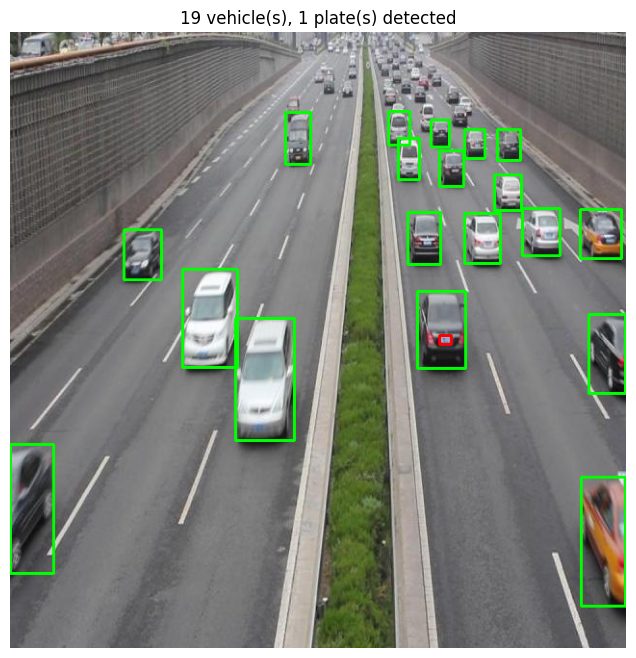

In [9]:
import matplotlib.pyplot as plt

img_vis = img.copy()
for d in detections:
    x1, y1, x2, y2 = d['vehicle_box']
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for p in d['plates']:
        px1, py1, px2, py2 = p['box']
        cv2.rectangle(img_vis, (px1, py1), (px2, py2), (0, 0, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"{len(detections)} vehicle(s), {sum(len(d['plates']) for d in detections)} plate(s) detected")
plt.show()

Best example: vehicle_subset/valid/images/MVI_40712_img01590_jpg.rf.f2e4fc1379eba35a2437a5b0691a82ae.jpg with 5 plates found


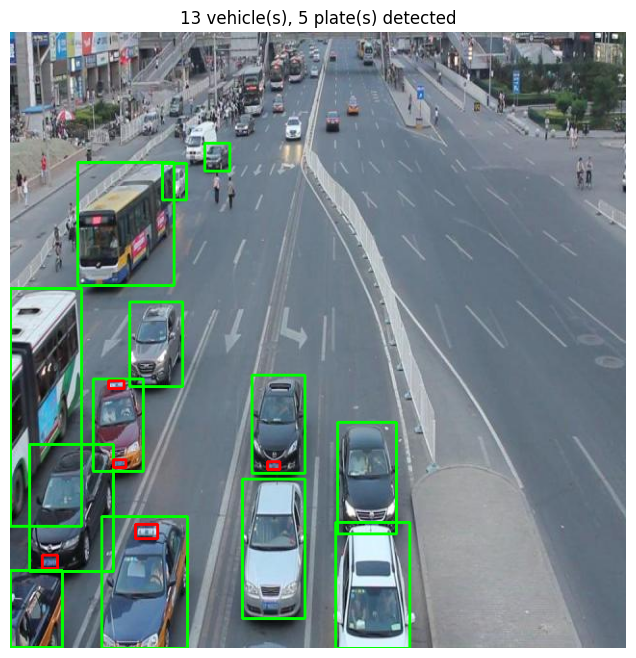

In [10]:
# Try a few images and show whichever has the most plates found
best_result = None
for img_name in test_images[:15]:
    path = f"vehicle_subset/valid/images/{img_name}"
    img_test, dets_test = detect_vehicles_and_plates(path, vehicle_model, plate_model)
    total_plates = sum(len(d['plates']) for d in dets_test)
    if best_result is None or total_plates > best_result[2]:
        best_result = (img_test, dets_test, total_plates, path)

img, detections, plate_count, best_path = best_result
print(f"Best example: {best_path} with {plate_count} plates found")

img_vis = img.copy()
for d in detections:
    x1, y1, x2, y2 = d['vehicle_box']
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for p in d['plates']:
        px1, py1, px2, py2 = p['box']
        cv2.rectangle(img_vis, (px1, py1), (px2, py2), (0, 0, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"{len(detections)} vehicle(s), {plate_count} plate(s) detected")
plt.show()

In [12]:
import time

def benchmark(weights_path, img, device, n_runs=30):
    model = YOLO(weights_path)  # fresh instance, avoids the fused-tensor bug
    model.to(device)
    for _ in range(5):
        model(img, verbose=False)
    start = time.time()
    for _ in range(n_runs):
        model(img, verbose=False)
    elapsed = time.time() - start
    avg_ms = (elapsed / n_runs) * 1000
    fps = 1000 / avg_ms
    return avg_ms, fps

test_img = cv2.imread(test_img_path)

vehicle_weights = "/content/runs/detect/runs/vehicle/v8n_vehicle/weights/best.pt"
plate_weights = "/content/runs/detect/runs/plate/v8n_plate/weights/best.pt"

print("Benchmarking vehicle model...")
v_gpu_ms, v_gpu_fps = benchmark(vehicle_weights, test_img, 'cuda:0')
v_cpu_ms, v_cpu_fps = benchmark(vehicle_weights, test_img, 'cpu')

print("Benchmarking plate model...")
p_gpu_ms, p_gpu_fps = benchmark(plate_weights, test_img, 'cuda:0')
p_cpu_ms, p_cpu_fps = benchmark(plate_weights, test_img, 'cpu')

print(f"\n{'Model':<10} {'Device':<6} {'Latency (ms)':<14} {'FPS':<8}")
print(f"{'Vehicle':<10} {'GPU':<6} {v_gpu_ms:<14.2f} {v_gpu_fps:<8.1f}")
print(f"{'Vehicle':<10} {'CPU':<6} {v_cpu_ms:<14.2f} {v_cpu_fps:<8.1f}")
print(f"{'Plate':<10} {'GPU':<6} {p_gpu_ms:<14.2f} {p_gpu_fps:<8.1f}")
print(f"{'Plate':<10} {'CPU':<6} {p_cpu_ms:<14.2f} {p_cpu_fps:<8.1f}")

Benchmarking vehicle model...
Benchmarking plate model...

Model      Device Latency (ms)   FPS     
Vehicle    GPU    9.63           103.8   
Vehicle    CPU    185.51         5.4     
Plate      GPU    7.82           128.0   
Plate      CPU    59.06          16.9    
